In [5]:
import pandas as pd

In [6]:
import numpy as np

In [7]:
print("Jupyter works!")

Jupyter works!


In [8]:
df =pd.read_csv(r"C:\Users\khade\OneDrive\Desktop\proj\Drugshortages.csv")

In [9]:
df.head()

,Generic Name,Company Name,Contact Info,Presentation,Type of Update,Date of Update,Availability Information,Related Information,Resolved Note,Reason for Shortage,...,Change Date,Date Discontinued,Initial Posting Date,Generic Name Note,Generic Name Link,Company Info Link,Availability Link,Related Info Link,Resolved Note Link,Discontinued Note Link
0,Acetaminophen; Oxycodone Hydrochloride Tablet,"Endo Pharmaceuticals, Inc.",800-828-9393,"Acetaminophen; Oxycodone Hydrochloride, Tablet...",New,11/03/2025,NaN,Discontinuation of the manufacture of the drug,NaN,NaN,...,NaN,11/03/2025,11/03/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Acetaminophen; Oxycodone Hydrochloride Tablet,"Endo Pharmaceuticals, Inc.",800-828-9393,"Acetaminophen; Oxycodone Hydrochloride, Tablet...",New,11/03/2025,NaN,Discontinuation of the manufacture of the drug,NaN,NaN,...,NaN,11/03/2025,11/03/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Acetaminophen; Oxycodone Hydrochloride Tablet,"Endo Pharmaceuticals, Inc.",800-828-9393,"Acetaminophen; Oxycodone Hydrochloride, Tablet...",New,11/03/2025,NaN,Discontinuation of the manufacture of the drug,NaN,NaN,...,NaN,11/03/2025,11/03/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Acetaminophen; Oxycodone Hydrochloride Tablet,"Endo Pharmaceuticals, Inc.",800-828-9393,"Acetaminophen; Oxycodone Hydrochloride, Tablet...",New,11/03/2025,NaN,Discontinuation of the manufacture of the drug,NaN,NaN,...,NaN,11/03/2025,11/03/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Acetaminophen; Oxycodone Hydrochloride Tablet,"Endo Pharmaceuticals, Inc.",800-828-9393,"Acetaminophen; Oxycodone Hydrochloride, Tablet...",New,11/03/2025,NaN,Discontinuation of the manufacture of the drug,NaN,NaN,...,NaN,11/03/2025,11/03/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1673 entries, 0 to 1672
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Generic Name               1673 non-null   str    
 1   Company Name               1673 non-null   str    
 2    Contact Info              1673 non-null   str    
 3    Presentation              1673 non-null   str    
 4    Type of Update            1673 non-null   str    
 5   Date of Update             1673 non-null   str    
 6    Availability Information  1149 non-null   str    
 7    Related Information       1163 non-null   str    
 8    Resolved Note             29 non-null     str    
 9    Reason for Shortage       433 non-null    str    
 10   Therapeutic Category      1673 non-null   str    
 11   Status                    1673 non-null   str    
 12   Change Date               37 non-null     str    
 13   Date Discontinued         494 non-null    str    
 14   In

In [11]:
df.columns

Index(['Generic Name', 'Company Name', ' Contact Info', ' Presentation',
       ' Type of Update', 'Date of Update', ' Availability Information',
       ' Related Information', ' Resolved Note', ' Reason for Shortage',
       ' Therapeutic Category', ' Status', ' Change Date',
       ' Date Discontinued', ' Initial Posting Date', ' Generic Name Note',
       ' Generic Name Link ', ' Company Info Link', ' Availability Link',
       ' Related Info Link', '   Resolved Note Link',
       ' Discontinued Note Link'],
      dtype='str')

In [12]:
df.isnull().sum()

Generic Name                    0
Company Name                    0
 Contact Info                   0
 Presentation                   0
 Type of Update                 0
Date of Update                  0
 Availability Information     524
 Related Information          510
 Resolved Note               1644
 Reason for Shortage         1240
 Therapeutic Category           0
 Status                         0
 Change Date                 1636
 Date Discontinued           1179
 Initial Posting Date           0
 Generic Name Note           1673
 Generic Name Link           1673
 Company Info Link           1673
 Availability Link           1673
 Related Info Link           1635
   Resolved Note Link        1673
 Discontinued Note Link      1673
dtype: int64

In [13]:
print(df.columns.tolist())

['Generic Name', 'Company Name', ' Contact Info', ' Presentation', ' Type of Update', 'Date of Update', ' Availability Information', ' Related Information', ' Resolved Note', ' Reason for Shortage', ' Therapeutic Category', ' Status', ' Change Date', ' Date Discontinued', ' Initial Posting Date', ' Generic Name Note', ' Generic Name Link ', ' Company Info Link', ' Availability Link', ' Related Info Link', '   Resolved Note Link', ' Discontinued Note Link']


In [14]:
# Fix all column names at once
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Generic Name', 'Company Name', 'Contact Info', 'Presentation', 'Type of Update', 'Date of Update', 'Availability Information', 'Related Information', 'Resolved Note', 'Reason for Shortage', 'Therapeutic Category', 'Status', 'Change Date', 'Date Discontinued', 'Initial Posting Date', 'Generic Name Note', 'Generic Name Link', 'Company Info Link', 'Availability Link', 'Related Info Link', 'Resolved Note Link', 'Discontinued Note Link']


In [15]:
# Cell 2 - Fix date columns
date_cols = ['Date of Update', 'Change Date', 'Date Discontinued', 'Initial Posting Date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(df[date_cols].dtypes)

Date of Update          datetime64[us]
Change Date             datetime64[us]
Date Discontinued       datetime64[us]
Initial Posting Date    datetime64[us]
dtype: object


In [16]:
for col in df.columns:
    print(repr(col))

'Generic Name'
'Company Name'
'Contact Info'
'Presentation'
'Type of Update'
'Date of Update'
'Availability Information'
'Related Information'
'Resolved Note'
'Reason for Shortage'
'Therapeutic Category'
'Status'
'Change Date'
'Date Discontinued'
'Initial Posting Date'
'Generic Name Note'
'Generic Name Link'
'Company Info Link'
'Availability Link'
'Related Info Link'
'Resolved Note Link'
'Discontinued Note Link'


In [17]:

from datetime import datetime

today = pd.Timestamp(datetime.today())
df['shortage_duration_days'] = (today - df['Initial Posting Date']).dt.days

print(df['shortage_duration_days'].describe())

count    1673.000000
mean     1527.592947
std      1300.940872
min         8.000000
25%       331.000000
50%      1182.000000
75%      2254.000000
max      5268.000000
Name: shortage_duration_days, dtype: float64


In [18]:

text_cols = ['Generic Name', 'Company Name', 'Therapeutic Category', 'Status', 'Type of Update']

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print(df['Status'].value_counts())
print("---")
print(df['Therapeutic Category'].value_counts().head(20))

Status
Current               1149
To Be Discontinued     495
Resolved                29
Name: count, dtype: int64
---
Therapeutic Category
Psychiatry                                                      244
Anesthesia                                                      232
Cardiovascular                                                  192
Analgesia/Addiction                                             135
Anti-Infective                                                   81
Oncology                                                         75
Endocrinology/Metabolism                                         65
Anesthesia; Pediatric                                            62
Endocrinology/Metabolism; Gastroenterology; Other; Pediatric     53
Neurology                                                        48
Neurology; Pediatric; Psychiatry                                 40
Rheumatology                                                     38
Gastroenterology                             

In [19]:
df['Availability Information'] = df['Availability Information'].fillna('Not Specified')
df['Reason for Shortage'] = df['Reason for Shortage'].fillna('Unknown')
df['Resolved Note'] = df['Resolved Note'].fillna('Not Resolved')

print(df.isnull().sum())

Generic Name                   0
Company Name                   0
Contact Info                   0
Presentation                   0
Type of Update                 0
Date of Update                 0
Availability Information       0
Related Information          510
Resolved Note                  0
Reason for Shortage            0
Therapeutic Category           0
Status                         0
Change Date                 1636
Date Discontinued           1179
Initial Posting Date           0
Generic Name Note           1673
Generic Name Link           1673
Company Info Link           1673
Availability Link           1673
Related Info Link           1635
Resolved Note Link          1673
Discontinued Note Link      1673
shortage_duration_days         0
dtype: int64


In [20]:
critical_keywords = ['oncology', 'anesthesia', 'cardiovascular', 
                     'anti-infective', 'hematology', 'antiviral',
                     'endocrinology', 'neurology']

df['is_critical'] = df['Therapeutic Category'].str.lower().str.contains(
    '|'.join(critical_keywords), na=False
).astype(int)

print(df['is_critical'].value_counts())
print(f"Critical shortages: {df['is_critical'].sum()} out of {len(df)}")

is_critical
1    1077
0     596
Name: count, dtype: int64
Critical shortages: 1077 out of 1673


In [21]:

# 1. Long shortage flag (over 365 days)
df['is_long_shortage'] = (df['shortage_duration_days'] > 365).astype(int)

# 2. Active shortage flag
df['is_active'] = (df['Status'] == 'Current').astype(int)

# 3. No availability info flag
df['no_availability'] = (df['Availability Information'] == 'Not Specified').astype(int)

# 4. Normalize duration to 0-1 scale
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['duration_normalized'] = scaler.fit_transform(df[['shortage_duration_days']])

print(df[['is_long_shortage', 'is_active', 'no_availability', 'duration_normalized']].head(10))

   is_long_shortage  is_active  no_availability  duration_normalized
0                 0          0                1             0.038973
1                 0          0                1             0.038973
2                 0          0                1             0.038973
3                 0          0                1             0.038973
4                 0          0                1             0.038973
5                 0          0                1             0.038973
6                 0          0                1             0.002281
7                 0          0                1             0.002281
8                 0          0                1             0.002281
9                 0          0                1             0.002281


In [22]:
pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
df['severity_score'] = (
    df['duration_normalized'] * 35 +      # 35% weight - how long it's been going
    df['is_critical'] * 25 +              # 25% weight - critical medical category
    df['is_active'] * 20 +                # 20% weight - still ongoing
    df['no_availability'] * 20            # 20% weight - no alternative info
).round(1)

# See the most severe shortages
top_shortages = df[['Generic Name', 'Therapeutic Category', 
                     'Status', 'shortage_duration_days', 
                     'severity_score']].sort_values('severity_score', ascending=False)

print(top_shortages.head(15))

                                          Generic Name  \
163                         Atropine Sulfate Injection   
160                         Atropine Sulfate Injection   
156                         Atropine Sulfate Injection   
166                         Atropine Sulfate Injection   
167                         Atropine Sulfate Injection   
168                         Atropine Sulfate Injection   
161                         Atropine Sulfate Injection   
157                         Atropine Sulfate Injection   
159                         Atropine Sulfate Injection   
162                         Atropine Sulfate Injection   
165                         Atropine Sulfate Injection   
941                  Lidocaine Hydrochloride Injection   
601  Epinephrine Bitartrate, Lidocaine Hydrochlorid...   
603  Epinephrine Bitartrate, Lidocaine Hydrochlorid...   
602  Epinephrine Bitartrate, Lidocaine Hydrochlorid...   

                 Therapeutic Category   Status  shortage_duration_days 

In [24]:
import sqlite3



In [25]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('drug_shortages.db')

query = """
SELECT "Therapeutic Category", 
       COUNT(*) as total_shortages,
       ROUND(AVG(shortage_duration_days), 0) as avg_duration_days,
       ROUND(AVG(severity_score), 1) as avg_severity
FROM shortages_clean
WHERE Status = 'Current'
GROUP BY "Therapeutic Category"
ORDER BY avg_severity DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
print(result)
conn.close()

                                Therapeutic Category  total_shortages  \
0                              Anesthesia; Pediatric               61   
1                   Anesthesia; Neurology; Pediatric               16   
2                          Anti-Infective; Pediatric                6   
3  Endocrinology/Metabolism; Gastroenterology; Pe...               10   
4                   Cardiovascular; Pediatric; Renal               10   
5  Endocrinology/Metabolism; Gastroenterology; Pe...               19   
6                                         Hematology               12   
7  Dermatology; Endocrinology/Metabolism; Gastroe...               16   
8                                         Anesthesia              224   
9                                          Neurology               17   

   avg_duration_days  avg_severity  
0             4879.0          77.5  
1             4261.0          73.3  
2             4122.0          72.4  
3             3771.0          70.1  
4          

In [26]:
df.columns

Index(['Generic Name', 'Company Name', 'Contact Info', 'Presentation',
       'Type of Update', 'Date of Update', 'Availability Information',
       'Related Information', 'Resolved Note', 'Reason for Shortage',
       'Therapeutic Category', 'Status', 'Change Date', 'Date Discontinued',
       'Initial Posting Date', 'Generic Name Note', 'Generic Name Link',
       'Company Info Link', 'Availability Link', 'Related Info Link',
       'Resolved Note Link', 'Discontinued Note Link',
       'shortage_duration_days', 'is_critical', 'is_long_shortage',
       'is_active', 'no_availability', 'duration_normalized',
       'severity_score'],
      dtype='str')

In [27]:
import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px
import plotly.graph_objects as go

# --- Page config ---
st.set_page_config(
    page_title="Drug Shortage Early Warning System",
    page_icon="💊",
    layout="wide"
)

# --- Load data ---
@st.cache_data
def load_data():
    conn = sqlite3.connect('drug_shortages.db')
    df = pd.read_sql("SELECT * FROM shortages_clean", conn)
    conn.close()
    return df

df = load_data()

# --- Header ---
st.title("💊 Drug Shortage Early Warning System")
st.markdown("Real-time FDA drug shortage intelligence for procurement teams")
st.divider()

# --- KPI Cards ---
col1, col2, col3, col4 = st.columns(4)

active = df[df['Status'] == 'Current']
critical = df[(df['Status'] == 'Current') & (df['is_critical'] == 1)]
avg_duration = int(df['shortage_duration_days'].mean())
high_risk = df[df['severity_score'] >= 70]

col1.metric("Active Shortages", len(active))
col2.metric("Critical Category Shortages", len(critical))
col3.metric("Avg Shortage Duration", f"{avg_duration} days")
col4.metric("High Risk (Score ≥ 70)", len(high_risk))

st.divider()

# --- Row 1: Two charts side by side ---
col_left, col_right = st.columns(2)

with col_left:
    st.subheader("Shortages by Therapeutic Category")
    cat_counts = (
        active.groupby('Therapeutic Category')
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .head(10)
    )
    fig1 = px.bar(
        cat_counts,
        x='count', y='Therapeutic Category',
        orientation='h',
        color='count',
        color_continuous_scale='Reds',
        labels={'count': 'Number of Shortages'}
    )
    fig1.update_layout(showlegend=False, yaxis={'categoryorder': 'total ascending'})
    st.plotly_chart(fig1, use_container_width=True)

with col_right:
    st.subheader("Shortage Status Breakdown")
    status_counts = df['Status'].value_counts().reset_index()
    status_counts.columns = ['Status', 'Count']
    fig2 = px.pie(
        status_counts,
        values='Count',
        names='Status',
        color_discrete_sequence=['#ef4444', '#f97316', '#22c55e']
    )
    st.plotly_chart(fig2, use_container_width=True)

st.divider()

# --- Row 2: Severity scatter ---
st.subheader("Severity vs Duration — Active Shortages")

fig3 = px.scatter(
    active,
    x='shortage_duration_days',
    y='severity_score',
    color='Therapeutic Category',
    hover_data=['Generic Name', 'Company Name', 'Status'],
    labels={
        'shortage_duration_days': 'Shortage Duration (Days)',
        'severity_score': 'Severity Score'
    },
    opacity=0.7
)
fig3.add_hline(y=70, line_dash="dash", line_color="red",
               annotation_text="High Risk Threshold (70)")
st.plotly_chart(fig3, use_container_width=True)

st.divider()

# --- Row 3: Risk table with filters ---
st.subheader("🔍 Drug Shortage Risk Table")

col_f1, col_f2, col_f3 = st.columns(3)

with col_f1:
    status_filter = st.selectbox("Filter by Status", 
                                  ['All'] + df['Status'].unique().tolist())
with col_f2:
    critical_filter = st.selectbox("Filter by Type", 
                                    ['All', 'Critical Only', 'Non-Critical'])
with col_f3:
    min_score = st.slider("Minimum Severity Score", 0, 100, 0)

# Apply filters
filtered = df.copy()
if status_filter != 'All':
    filtered = filtered[filtered['Status'] == status_filter]
if critical_filter == 'Critical Only':
    filtered = filtered[filtered['is_critical'] == 1]
elif critical_filter == 'Non-Critical':
    filtered = filtered[filtered['is_critical'] == 0]
filtered = filtered[filtered['severity_score'] >= min_score]

# Color code severity
def color_severity(val):
    if val >= 70:
        return 'background-color: #fee2e2'
    elif val >= 40:
        return 'background-color: #fef9c3'
    else:
        return 'background-color: #dcfce7'

display_cols = ['Generic Name', 'Therapeutic Category', 'Company Name',
                'Status', 'shortage_duration_days', 'severity_score']

st.dataframe(
    filtered[display_cols]
    .sort_values('severity_score', ascending=False)
    .style.map(color_severity, subset=['severity_score']),
    use_container_width=True,
    height=400
)

st.caption(f"Showing {len(filtered)} of {len(df)} records")

st.divider()

# --- Row 4: Drug deep dive ---
st.subheader("🔎 Drug Deep Dive")

selected_drug = st.selectbox(
    "Select a drug to inspect",
    df['Generic Name'].sort_values().unique()
)

drug_data = df[df['Generic Name'] == selected_drug]

if not drug_data.empty:
    row = drug_data.iloc[0]
    
    d1, d2, d3 = st.columns(3)
    d1.metric("Severity Score", row['severity_score'])
    d2.metric("Duration (Days)", int(row['shortage_duration_days']))
    d3.metric("Status", row['Status'])
    
    st.markdown(f"**Company:** {row['Company Name']}")
    st.markdown(f"**Category:** {row['Therapeutic Category']}")
    st.markdown(f"**Availability Info:** {row['Availability Information']}")
    st.markdown(f"**Reason for Shortage:** {row['Reason for Shortage']}")

    # Severity gauge
    fig4 = go.Figure(go.Indicator(
        mode="gauge+number",
        value=row['severity_score'],
        title={'text': "Severity Score"},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': "darkred"},
            'steps': [
                {'range': [0, 40], 'color': "#dcfce7"},
                {'range': [40, 70], 'color': "#fef9c3"},
                {'range': [70, 100], 'color': "#fee2e2"}
            ],
            'threshold': {
                'line': {'color': "red", 'width': 4},
                'thickness': 0.75,
                'value': 70
            }
        }
    ))
    st.plotly_chart(fig4, use_container_width=True)

2026-06-04 11:13:07.708 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 11:13:07.710 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-04 11:13:07.711 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-04 11:13:07.712 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 11:13:07.724 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


KeyboardInterrupt: 

In [ ]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import subprocess
subprocess.Popen(['streamlit', 'run', 'app.py'])

<Popen: returncode: None args: ['streamlit', 'run', 'app.py']>

In [ ]:
import os
print(os.getcwd())


c:\Users\khade\OneDrive\Desktop\My Programs\notebook


In [ ]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\khade\OneDrive\Desktop\My Programs\notebook
['.git', 'app.py', 'drug_shortages.db', 'README.md', 'test.ipynb']


In [28]:
# Predict whether a shortage will last over 365 days
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

features = ['is_critical', 'no_availability', 'duration_normalized']
df['long_shortage_label'] = (df['shortage_duration_days'] > 365).astype(int)

X = df[features]
y = df['long_shortage_label']

model = XGBClassifier(max_depth=3, random_state=42)
scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"AUC: {scores.mean():.3f}")

AUC: 0.996


In [ ]:
import shap

model.fit(X, y)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\khade\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\khade\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "C:\Users\khade\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

AttributeError: _ARRAY_API not found

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


NameError: name 'model' is not defined

In [ ]:

pip install shap==0.44.1

                                              0.0/450.3 kB ? eta -:--:--
     --------                               102.4/450.3 kB 2.0 MB/s eta 0:00:01
     -------------------------------------- 450.3/450.3 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: slicer
    Found existing installation: slicer 0.0.8
    Uninstalling slicer-0.0.8:
      Successfully uninstalled slicer-0.0.8
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import subprocess
subprocess.run(['pip', 'uninstall', 'shap', 'numpy', '-y'])
subprocess.run(['pip', 'install', 'numpy==1.26.4'])
subprocess.run(['pip', 'install', 'shap==0.44.1'])

CompletedProcess(args=['pip', 'install', 'shap==0.44.1'], returncode=0)

In [ ]:
pip uninstall shap numpy -y
pip install numpy==1.26.4
pip install shap==0.44.1

In [7]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import sqlite3
from sklearn.preprocessing import MinMaxScaler


In [8]:
#connect sql 

conn = sqlite3.connect(r"C:\Users\khade\OneDrive\Desktop\My Programs\notebook\drug_shortages.db")

df = pd.read_sql("SELECT * FROM shortages_clean",conn)
conn.close()

print(df.shape)
print(df.columns.tolist())

(1673, 22)
['Generic Name', 'Company Name', 'Contact Info', 'Presentation', 'Type of Update', 'Date of Update', 'Availability Information', 'Related Information', 'Resolved Note', 'Reason for Shortage', 'Therapeutic Category', 'Status', 'Change Date', 'Date Discontinued', 'Initial Posting Date', 'shortage_duration_days', 'is_critical', 'is_long_shortage', 'is_active', 'no_availability', 'duration_normalized', 'severity_score']


In [9]:
from datetime import datetime

today = pd.Timestamp(datetime.today())
df['shortage_duration_days']=(today-pd.to_datetime(df['Initial Posting Date'])).dt.days

scaler= MinMaxScaler()
df['duration_normalized']=scaler.fit_transform(df[['shortage_duration_days']])

critical_keywords = ['oncology', 'anesthesia', 'cardiovascular',
                     'anti-infective', 'hematology', 'antiviral',
                     'endocrinology', 'neurology']

df['is_critical'] = df['Therapeutic Category'].str.lower().str.contains(
    '|'.join(critical_keywords),na=False
).astype(int)

df['Availability Information'] = df['Availability Information'].fillna('Not Specified')
df['no_availability'] = (df['Availability Information'] == 'Not Specified').astype(int)

# Active flag
df['is_active'] = (df['Status'] == 'Current').astype(int)

# Severity score
df['severity_score'] = (
    df['duration_normalized'] * 35 +
    df['is_critical'] * 25 +
    df['is_active'] * 20 +
    df['no_availability'] * 20
).round(1)

print(df[['shortage_duration_days', 'is_critical', 
          'no_availability', 'severity_score']].head(14))

    shortage_duration_days  is_critical  no_availability  severity_score
0                      213            0                1            21.4
1                      213            0                1            21.4
2                      213            0                1            21.4
3                      213            0                1            21.4
4                      213            0                1            21.4
5                      213            0                1            21.4
6                       20            0                1            20.1
7                       20            0                1            20.1
8                       20            0                1            20.1
9                       20            0                1            20.1
10                      20            0                1            20.1
11                     142            0                1            20.9
12                     142            0            

In [10]:
features = ['is_critical','no_availability','duration_normalized','is_active']

df['long_shortage_label'] = (df['shortage_duration_days'] > 365).astype(int)

X= df[features]
y = df['long_shortage_label']

print(f"Class distribution: \n{y.value_counts()}")
print(f"Feature shape: {X.shape}")

Class distribution: 
long_shortage_label
1    1185
0     488
Name: count, dtype: int64
Feature shape: (1673, 4)


In [11]:
model = XGBClassifier(max_depth = 3, random_state = 42, eval_metric='logloss')

scores = cross_val_score(model, X,y, cv=5,scoring='roc_auc')

print(f"AUC scores per fold: {scores.mean():.3f}")
print(f"Std: {scores.std():.3f}")

AUC scores per fold: 0.992
Std: 0.015


In [12]:
# Cell 6 - fit model on full data for SHAP
model.fit(X, y)
print("Model trained successfully")

Model trained successfully


Feature Importance Values:
               feature  importance
2  duration_normalized         1.0
0          is_critical         0.0
1      no_availability         0.0
3            is_active         0.0



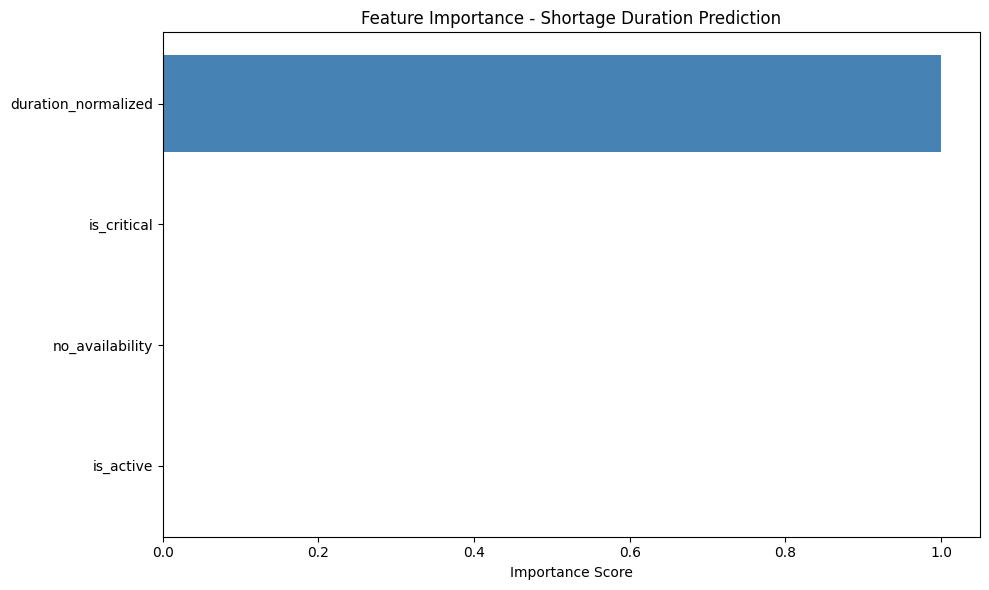

In [13]:


# Cell 7 - Feature importance from XGBoost model
import matplotlib.pyplot as plt
import pandas as pd

# Create importance dataframe
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance Values:")
print(importance_df)
print()

# Create bar plot manually
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance - Shortage Duration Prediction')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [18]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# Cell 8 - save updated dataframe back to database
conn = sqlite3.connect(r'c:\Users\khade\OneDrive\Desktop\My Programs\notebook\drug_shortages.db')
df.to_sql('shortages_clean', conn, if_exists='replace', index=False)
conn.close()
print("Database updated successfully")

Database updated successfully
